<a href="https://colab.research.google.com/github/miaowangcissy/animal_behavior_analysis_in_python/blob/main/day3_movement_ecology/Day4_Project1_SkeletonKinematics_Findley.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐭 Day 4 — Project 1: From Markers to Behavioral States
## Skeleton Kinematics & Movement Motif Discovery
*Inspired by Findley et al. (2021) — "Sniff-synchronized, gradient-guided olfactory search by freely moving mice"*

---

### Learning Objectives
By the end of this session you will be able to:

1. **Extract skeleton-based kinematic features** from noisy DLC tracking data (nose speed, yaw velocity)
2. **Visualize the mouse skeleton** across time to build intuition about posture
3. **Compare kinematics** during object interaction vs. free exploration
4. **Discover movement motifs** using unsupervised methods (sliding-window + clustering)
5. **Build transition matrices** to reveal higher-order behavioral structure

### Connection to the Paper
Findley et al. tracked **three body points** (snout tip, back of head, center of mass) and computed:
- **Nose speed**: displacement of the snout tip per frame
- **Yaw velocity**: change in angle between snout–head and head–body segments (head casting)
- **Z-velocity**: change in snout–head distance (vertical movement proxy)

They used an **AR-HMM** to parse trajectories into discrete motifs, which clustered into two behavioral states: *investigation* and *approach*.

**Our adaptation**: We use the same DLC data from the Day 2 object interaction task (nose, head, spine1, spine2). Since we lack height information, we skip Z-velocity and instead focus on nose speed, yaw velocity, body length dynamics, and a simplified motif discovery pipeline.

### Prerequisites
- Completed the **Day 2 notebook** (Mouse–Object Interaction Analysis)
- Familiar with: loading DLC data, likelihood filtering, speed calculation, object interaction detection

---
## 🔧 Setup

In [1]:
# Install any extra packages if needed
!pip install ruptures --quiet  # for change-point detection (motifs)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy.ndimage import uniform_filter1d
from scipy.signal import savgol_filter
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ──
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        11,
})

# Colorblind-friendly palette
CB_COLORS = ['#0077BB', '#EE7733', '#009988', '#CC3311', '#33BBEE', '#EE3377']

print("✓ All packages imported successfully!")

✓ All packages imported successfully!


---
## Part 1: Load & Prepare Data (from Day 2)

We reuse the same dataset and cleaning pipeline from the Day 2 notebook.
If you already ran that notebook, this section will feel familiar — we're just getting back
to a clean, filtered DataFrame with all the body-part coordinates.

In [65]:
# ─────────────────────────────────────────────────────────────
# Load the DLC tracking data and object positions (same as Day 2)
# ─────────────────────────────────────────────────────────────
FPS = 20

!curl -sO https://raw.githubusercontent.com/miaowangcissy/animal_behavior_analysis_in_python/main/data/object_recg/extracted_trajectory.csv
raw = pd.read_csv('extracted_trajectory.csv', header=[0, 1, 2], index_col=0)
raw.columns = ['_'.join(col[1:]).strip() for col in raw.columns]
raw.index.name = 'frame'
dlc_raw = raw.reset_index()
dlc_raw['frame'] = dlc_raw['frame'].astype(int)
dlc_raw['time']  = dlc_raw['frame'] / FPS
DURATION = len(dlc_raw) / FPS

rename_dict = {'soine1_x': 'spine1_x', 'soine1_y': 'spine1_y',
               'soine1_likelihood': 'spine1_likelihood'}
dlc_raw.rename(columns=rename_dict, inplace=True)

# Load object centers

!curl -sO https://raw.githubusercontent.com/miaowangcissy/animal_behavior_analysis_in_python/main/data/object_recg/object_centers.csv
obj_df = pd.read_csv('object_centers.csv')


print(f"✓ Loaded {len(dlc_raw)} frames ({DURATION:.1f} s) at {FPS} fps")
print(f"✓ {len(obj_df)} objects detected")
print(f"\nColumns: {list(dlc_raw.columns[:12])} ...")

✓ Loaded 18032 frames (901.6 s) at 20 fps
✓ 3 objects detected

Columns: ['frame', 'nose_x', 'nose_y', 'nose_likelihood', 'head_x', 'head_y', 'head_likelihood', 'spine1_x', 'spine1_y', 'spine1_likelihood', 'spine2_x', 'spine2_y'] ...


In [37]:
obj_df

,object,center_x,center_y,bbox_x1,bbox_y1,bbox_x2,bbox_y2
0,object_1_square,155,167,119,131,198,209
1,object_2_circle,364,177,321,133,411,223
2,object_3_cylinder,390,412,362,384,418,440


In [8]:
# ─────────────────────────────────────────────────────────────
# Quality control: likelihood filter + interpolation (Day 2 recap)
# ─────────────────────────────────────────────────────────────
BODYPARTS   = ['nose', 'head', 'spine1', 'spine2']
LIKE_THRESH = 0.5

def filter_and_interpolate(df, bodyparts, threshold=0.6, max_gap_frames=10):
    clean = df.copy()
    for bp in bodyparts:
        like_col = f'{bp}_likelihood'
        mask = clean[like_col] < threshold
        for coord in ['x', 'y']:
            col = f'{bp}_{coord}'
            clean.loc[mask, col] = np.nan
        clean.loc[mask, like_col] = np.nan
    # Interpolate short gaps
    for bp in bodyparts:
        for coord in ['x', 'y']:
            col = f'{bp}_{coord}'
            clean[col] = clean[col].interpolate(method='linear', limit=max_gap_frames)
    return clean

dlc_clean = filter_and_interpolate(dlc_raw, BODYPARTS, LIKE_THRESH)

# Smooth
SMOOTH_WINDOW = 3
dlc = dlc_clean.copy()
for bp in BODYPARTS:
    for coord in ['x', 'y']:
        col = f'{bp}_{coord}'
        dlc[col] = uniform_filter1d(dlc[col].values, size=SMOOTH_WINDOW)

print(f"✓ Data cleaned and smoothed (window={SMOOTH_WINDOW} frames)")
nan_pct = dlc[['nose_x', 'head_x', 'spine1_x', 'spine2_x']].isna().mean() * 100
print(f"  Remaining NaN%: nose={nan_pct['nose_x']:.1f}%, head={nan_pct['head_x']:.1f}%, "
      f"spine1={nan_pct['spine1_x']:.1f}%, spine2={nan_pct['spine2_x']:.1f}%")

✓ Data cleaned and smoothed (window=3 frames)
  Remaining NaN%: nose=99.6%, head=99.5%, spine1=93.6%, spine2=97.6%


In [16]:
dlc = dlc_raw

---
## Part 2: Visualizing the Mouse Skeleton

Before extracting features, let's build intuition by **visualizing the tracked skeleton**.
Our DLC model tracks 4 body points: `nose → head → spine1 → spine2`.
Connected, they form a simple "stick figure" of the mouse.

This is analogous to what Findley et al. did with their three tracked points (snout, head, center of mass).
Visualizing the skeleton helps us:
- Spot tracking errors visually
- Understand what "yaw" and "body elongation" look like in practice
- Build intuition before diving into math

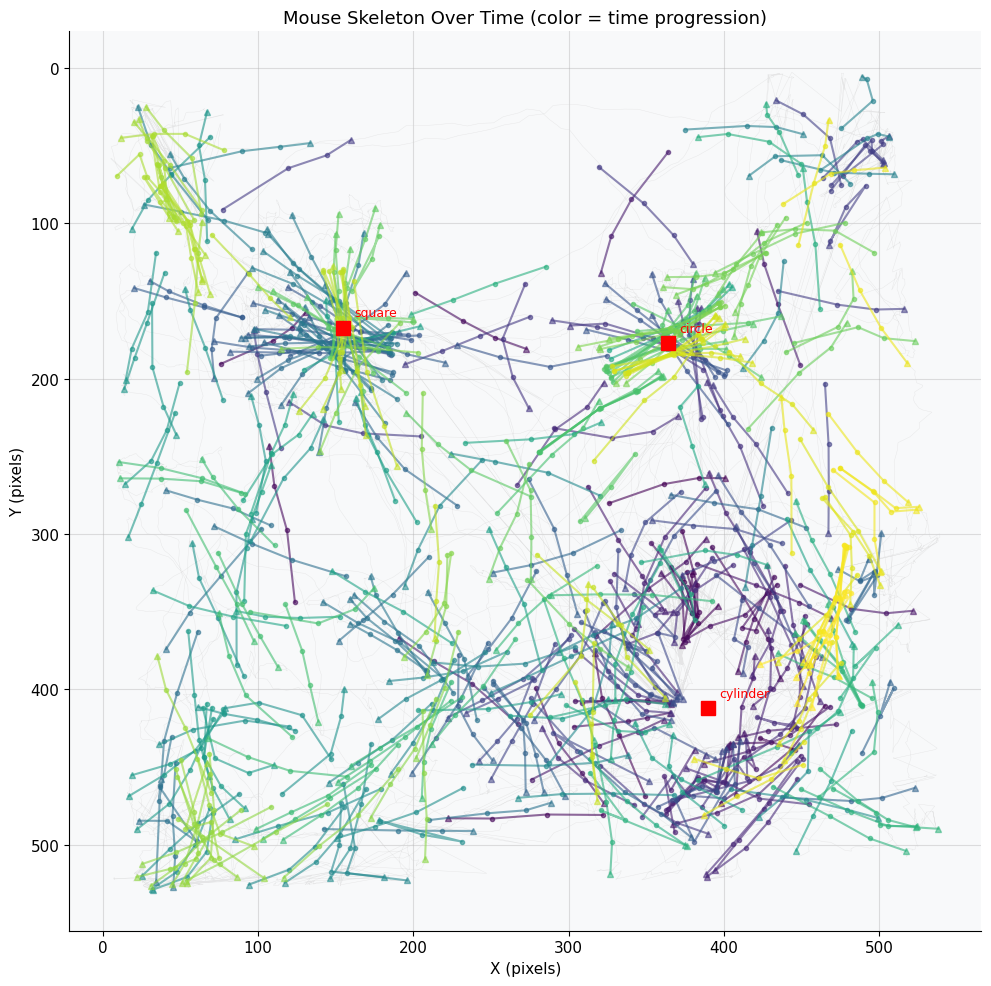

In [38]:
# ─────────────────────────────────────────────────────────────
# Skeleton visualization: draw the mouse at selected frames
# ─────────────────────────────────────────────────────────────

def draw_skeleton(ax, row, color='k', alpha=1.0, head_size=30, nose_size=20):
    """Draw the 4-point mouse skeleton on an axis."""
    pts = np.array([
        [row['nose_x'],   row['nose_y']],
        [row['head_x'],   row['head_y']],
        [row['spine1_x'], row['spine1_y']],
        [row['spine2_x'], row['spine2_y']],
    ])
    # Skip if any NaN
    if np.any(np.isnan(pts)):
        return
    # Body line
    ax.plot(pts[:, 0], pts[:, 1], '-', color=color, alpha=alpha, linewidth=1.5)
    # Joints
    ax.plot(pts[1:, 0], pts[1:, 1], 'o', color=color, alpha=alpha, markersize=3)
    # Nose — triangle marker
    ax.plot(pts[0, 0], pts[0, 1], '^', color=color, alpha=alpha*0.9, markersize=5)


# Draw skeleton every N frames over the trajectory
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Background: full trajectory (light)
ax.plot(dlc['nose_x'], dlc['nose_y'], '-', color='lightgray', linewidth=0.3, alpha=0.5)

# Draw skeletons every 40 frames (~2 seconds)
step = 40
cmap = plt.cm.viridis
n_skeletons = len(dlc) // step
for i, idx in enumerate(range(0, len(dlc), step)):
    row = dlc.iloc[idx]
    color = cmap(i / n_skeletons)
    draw_skeleton(ax, row, color=color, alpha=0.6)

# Mark objects
for _, obj_row in obj_df.iterrows():
    ax.plot(obj_row['center_x'], obj_row['center_y'], 's', color='red', markersize=10)
    ax.annotate(obj_row['object'].split('_')[-1],
                (obj_row['center_x'], obj_row['center_y']),
                textcoords="offset points", xytext=(8, 8), fontsize=9, color='red')

ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')
ax.set_title('Mouse Skeleton Over Time (color = time progression)', fontsize=13)
ax.set_aspect('equal')
ax.invert_yaxis()  # video coordinates
plt.tight_layout()
plt.show()

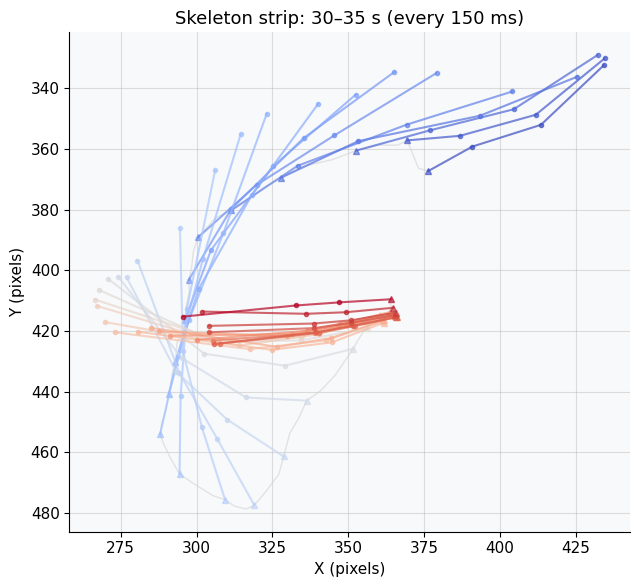

Tip: try changing t_start_s and t_end_s to explore different parts of the trajectory!


In [18]:
# ─────────────────────────────────────────────────────────────
# Zoom into a short segment: animate-like strip of skeletons
# ─────────────────────────────────────────────────────────────
t_start_s, t_end_s = 30, 35  # 5-second window
mask = (dlc['time'] >= t_start_s) & (dlc['time'] <= t_end_s)
segment = dlc[mask]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(segment['nose_x'], segment['nose_y'], '-', color='lightgray', linewidth=1, alpha=0.6)

step_zoom = 3  # every 3 frames = 150 ms
n_skel = len(segment) // step_zoom
for i, (_, row) in enumerate(segment.iloc[::step_zoom].iterrows()):
    color = plt.cm.coolwarm(i / max(n_skel, 1))
    draw_skeleton(ax, row, color=color, alpha=0.7)

ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')
ax.set_title(f'Skeleton strip: {t_start_s}–{t_end_s} s (every {step_zoom * 1000/FPS:.0f} ms)', fontsize=13)
ax.set_aspect('equal')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Tip: try changing t_start_s and t_end_s to explore different parts of the trajectory!")

---
## Part 3: Kinematic Feature Extraction (Findley-Style)

Now we extract the key kinematic features inspired by Findley et al. (2021).

### 3.1 Nose Speed

The most basic kinematic: how fast is the snout tip moving?

$$v_{\text{nose}}[t] = \frac{\sqrt{(x_{\text{nose}}[t] - x_{\text{nose}}[t-1])^2 + (y_{\text{nose}}[t] - y_{\text{nose}}[t-1])^2}}{\Delta t}$$

In Findley et al., nose speed peaks at inhalation onset during olfactory search. In our task, we expect nose speed to change during object investigation vs. free locomotion.

In [19]:
# ─────────────────────────────────────────────────────────────
# 3.1 Nose speed
# ─────────────────────────────────────────────────────────────
dt = 1.0 / FPS  # seconds per frame
## TODO: Compute nose speed as the frame-to-frame distance traveled by the nose divided by dt
nose_speed = None
# Pad to match DataFrame length (first frame has no speed)
dlc['nose_speed'] = np.concatenate([[np.nan], nose_speed])

# Light smoothing to reduce noise
dlc['nose_speed_smooth'] = uniform_filter1d(
    dlc['nose_speed'].fillna(0).values, size=5
)

print(f"Nose speed: mean = {np.nanmean(nose_speed):.1f} px/s, "
      f"median = {np.nanmedian(nose_speed):.1f} px/s, "
      f"max = {np.nanmax(nose_speed):.1f} px/s")

Nose speed: mean = 76.4 px/s, median = 32.9 px/s, max = 8583.9 px/s


In [ ]:


dx = np.diff(dlc['nose_x'].values)
dy = np.diff(dlc['nose_y'].values)
nose_speed = np.sqrt(dx**2 + dy**2) / dt  # pixels/s


### 3.2 Yaw Velocity (Head Casting)

This is the key feature from Findley et al. that captures **lateral head scanning** — the rapid side-to-side movements mice make while investigating odors.

**Definition (2D adaptation):** We define yaw as the angle between two body segments:
1. The **snout–head** segment (front of the head)
2. The **head–spine1** segment (back of the head / neck)

The angle between these two segments tells us how much the nose is "bent" relative to the body axis.

$$\theta_{\text{front}} = \text{atan2}(y_{\text{nose}} - y_{\text{head}},\; x_{\text{nose}} - x_{\text{head}})$$

$$\theta_{\text{back}} = \text{atan2}(y_{\text{head}} - y_{\text{spine1}},\; x_{\text{head}} - x_{\text{spine1}})$$

$$\text{yaw}[t] = \theta_{\text{front}}[t] - \theta_{\text{back}}[t]$$

$$\text{yaw velocity}[t] = \frac{\Delta\text{yaw}}{\Delta t}$$

The yaw angle captures the **bending** of the head relative to the body, and its derivative (yaw velocity) captures the **rate of head casting**. Positive yaw velocity = turning one way, negative = turning the other way.

In [20]:
# ─────────────────────────────────────────────────────────────
# 3.2 Yaw angle and yaw velocity
# ─────────────────────────────────────────────────────────────

# Angle of front segment: nose → head
theta_front = np.arctan2(
    dlc['nose_y'].values - dlc['head_y'].values,
    dlc['nose_x'].values - dlc['head_x'].values
)

# Angle of back segment: head → spine1
theta_back = np.arctan2(
    dlc['head_y'].values - dlc['spine1_y'].values,
    dlc['head_x'].values - dlc['spine1_x'].values
)

# Yaw angle: difference (unwrap to avoid ±π jumps)
yaw_raw = theta_front - theta_back
# Wrap to [-π, π]
yaw_angle = np.arctan2(np.sin(yaw_raw), np.cos(yaw_raw))

dlc['yaw_angle'] = yaw_angle

# Yaw velocity: rate of change of yaw
dyaw = np.diff(yaw_angle)
# Wrap the difference
dyaw = np.arctan2(np.sin(dyaw), np.cos(dyaw))
yaw_velocity = dyaw / dt  # rad/s

dlc['yaw_velocity'] = np.concatenate([[np.nan], yaw_velocity])

# Smooth yaw velocity
dlc['yaw_velocity_smooth'] = uniform_filter1d(
    dlc['yaw_velocity'].fillna(0).values, size=5
)

print(f"Yaw angle:    mean = {np.degrees(np.nanmean(yaw_angle)):.1f}°, "
      f"std = {np.degrees(np.nanstd(yaw_angle)):.1f}°")
print(f"Yaw velocity: mean = {np.degrees(np.nanmean(yaw_velocity)):.1f}°/s, "
      f"std = {np.degrees(np.nanstd(yaw_velocity)):.1f}°/s")

Yaw angle:    mean = -3.2°, std = 45.9°
Yaw velocity: mean = -5.2°/s, std = 505.4°/s


### 3.3 Body Length (Elongation Proxy)

Body length (nose to spine2 distance) serves as a proxy for **postural extension**.
- **Stretched body** → the animal is reaching out to investigate
- **Compressed body** → the animal is hunching, grooming, or turning

This is analogous to the Z-velocity measure in Findley et al. (which captured snout-to-head distance changes, confounding pitch and z-translation). Since we lack height data, body length is our best 2D proxy.

$$L_{\text{body}}[t] = \sqrt{(x_{\text{nose}}[t] - x_{\text{spine2}}[t])^2 + (y_{\text{nose}}[t] - y_{\text{spine2}}[t])^2}$$

In [21]:
# ─────────────────────────────────────────────────────────────
# 3.3 Body length (nose to spine2)
# ─────────────────────────────────────────────────────────────
## TODO: Compute body length as distance from nose to spine2
body_length = None 
dlc['body_length'] = body_length

# Rate of change of body length (elongation velocity)
dlc['body_length_vel'] = np.concatenate([[np.nan],
    np.diff(body_length.values) / dt
])

print(f"Body length: mean = {np.nanmean(body_length):.1f} px, "
      f"std = {np.nanstd(body_length):.1f} px")

Body length: mean = 77.7 px, std = 23.7 px


In [ ]:
# body_length = np.sqrt(
#     (dlc['nose_x'] - dlc['spine2_x'])**2 +
#     (dlc['nose_y'] - dlc['spine2_y'])**2
# )

### 3.4 Body Axis Orientation & Angular Velocity

The overall **heading direction** of the body (spine2 → head vector) and how fast it turns.

In [22]:
# ─────────────────────────────────────────────────────────────
# 3.4 Body axis orientation and angular velocity
# ─────────────────────────────────────────────────────────────
body_angle = np.arctan2(
    dlc['head_y'].values - dlc['spine2_y'].values,
    dlc['head_x'].values - dlc['spine2_x'].values
)
dlc['body_angle'] = body_angle

d_body_angle = np.diff(body_angle)
d_body_angle = np.arctan2(np.sin(d_body_angle), np.cos(d_body_angle))
dlc['body_angular_vel'] = np.concatenate([[np.nan], d_body_angle / dt])

print("✓ All kinematic features computed:")
print("  nose_speed, yaw_angle, yaw_velocity, body_length, body_length_vel, body_angle, body_angular_vel")

✓ All kinematic features computed:
  nose_speed, yaw_angle, yaw_velocity, body_length, body_length_vel, body_angle, body_angular_vel


---
## Part 4: Visualize Kinematic Features

Let's plot all our extracted features over time to build intuition.

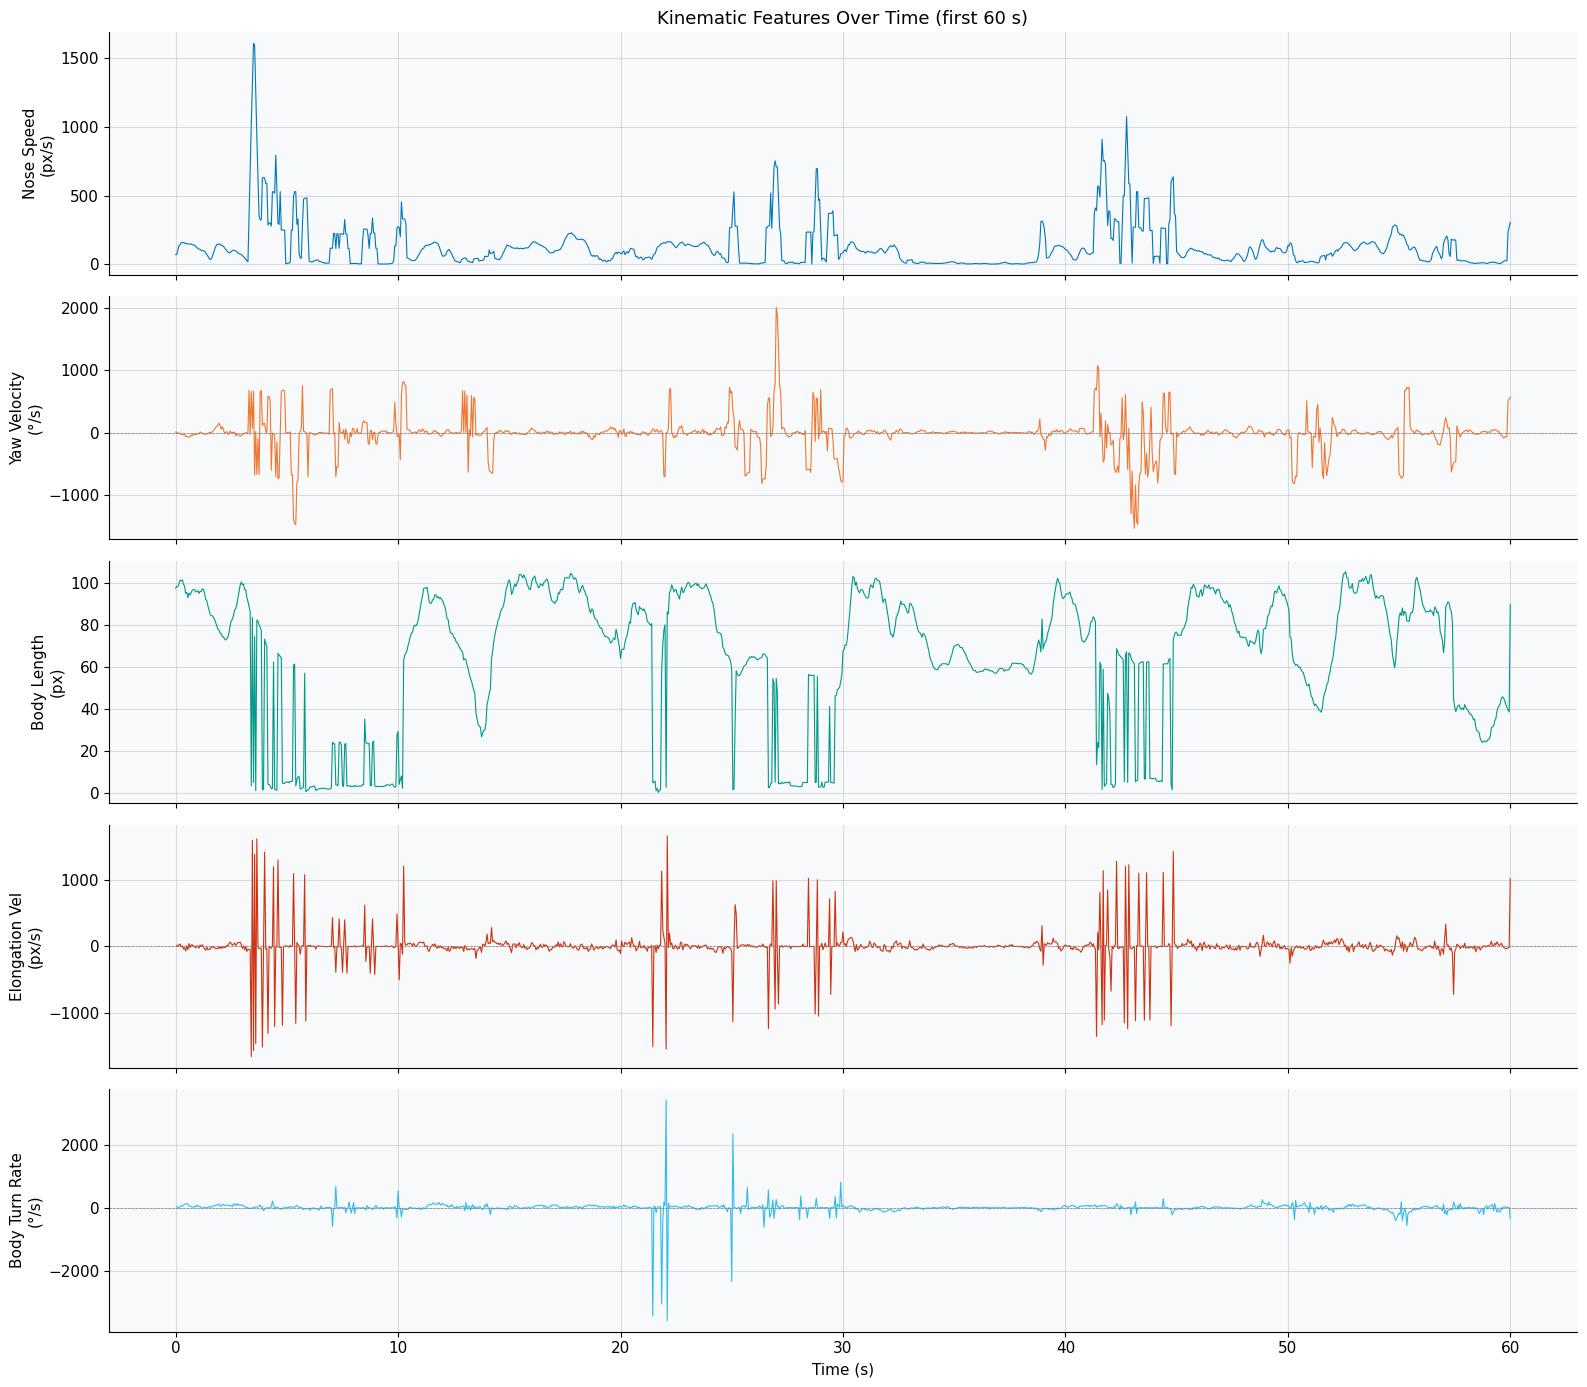

In [23]:
# ─────────────────────────────────────────────────────────────
# Time series of all kinematic features (first 60 seconds)
# ─────────────────────────────────────────────────────────────
t_mask = dlc['time'] <= 60
t = dlc.loc[t_mask, 'time']

fig, axes = plt.subplots(5, 1, figsize=(16, 14), sharex=True)

# Nose speed
axes[0].plot(t, dlc.loc[t_mask, 'nose_speed_smooth'], color=CB_COLORS[0], linewidth=0.8)
axes[0].set_ylabel('Nose Speed\n(px/s)')
axes[0].set_title('Kinematic Features Over Time (first 60 s)', fontsize=13)

# Yaw velocity
axes[1].plot(t, np.degrees(dlc.loc[t_mask, 'yaw_velocity_smooth']), color=CB_COLORS[1], linewidth=0.8)
axes[1].axhline(0, color='gray', linewidth=0.5, linestyle='--')
axes[1].set_ylabel('Yaw Velocity\n(°/s)')

# Body length
axes[2].plot(t, dlc.loc[t_mask, 'body_length'], color=CB_COLORS[2], linewidth=0.8)
axes[2].set_ylabel('Body Length\n(px)')

# Body elongation velocity
axes[3].plot(t, dlc.loc[t_mask, 'body_length_vel'], color=CB_COLORS[3], linewidth=0.8)
axes[3].axhline(0, color='gray', linewidth=0.5, linestyle='--')
axes[3].set_ylabel('Elongation Vel\n(px/s)')

# Body angular velocity
axes[4].plot(t, np.degrees(dlc.loc[t_mask, 'body_angular_vel']), color=CB_COLORS[4], linewidth=0.8)
axes[4].axhline(0, color='gray', linewidth=0.5, linestyle='--')
axes[4].set_ylabel('Body Turn Rate\n(°/s)')
axes[4].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

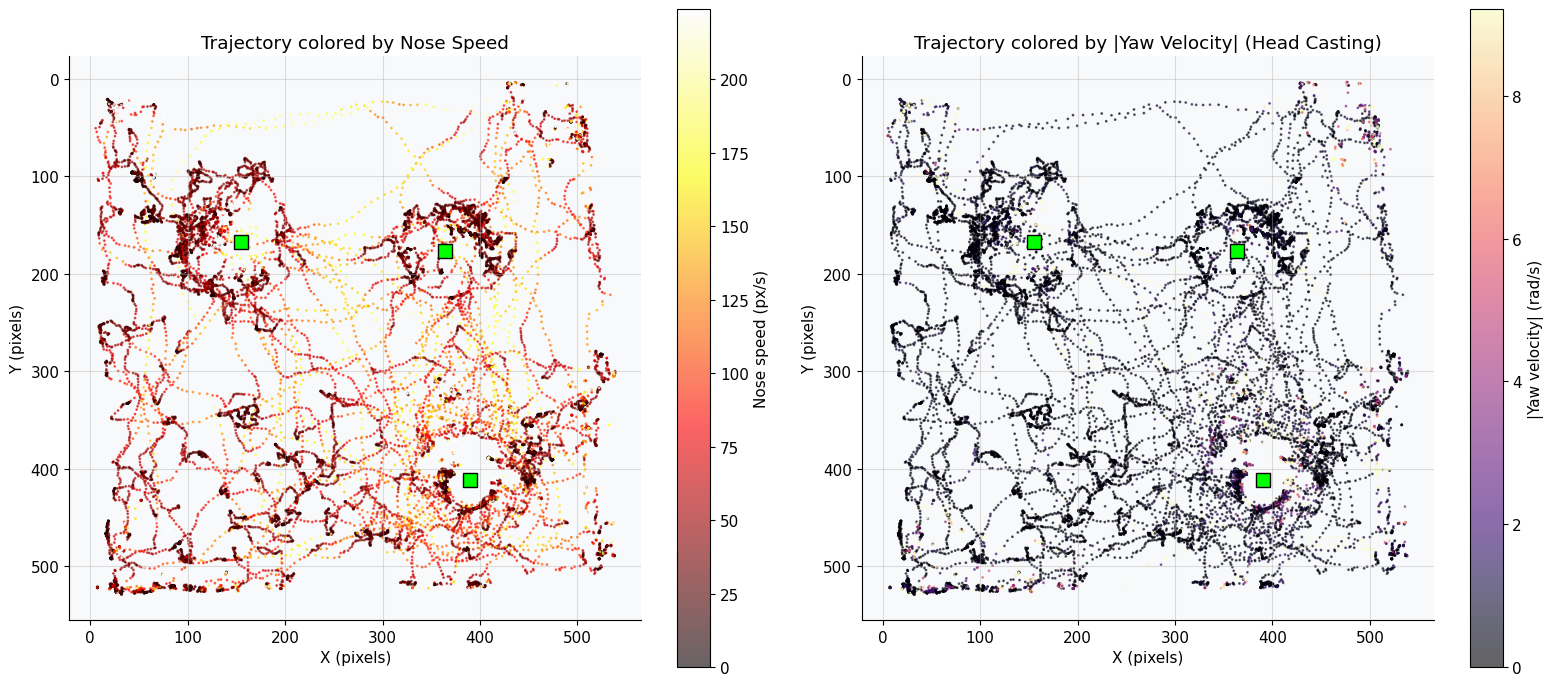

In [56]:
# ─────────────────────────────────────────────────────────────
# Trajectory colored by yaw velocity magnitude (head casting intensity)
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: colored by nose speed
sc1 = axes[0].scatter(dlc['nose_x'], dlc['nose_y'],
                       c=dlc['nose_speed_smooth'], cmap='hot', s=1, alpha=0.6,
                       vmin=0, vmax=np.nanpercentile(dlc['nose_speed_smooth'], 95))
plt.colorbar(sc1, ax=axes[0], label='Nose speed (px/s)')
axes[0].set_title('Trajectory colored by Nose Speed')
axes[0].set_aspect('equal')
axes[0].invert_yaxis()

# Right: colored by absolute yaw velocity
yaw_abs = np.abs(dlc['yaw_velocity_smooth'])
sc2 = axes[1].scatter(dlc['nose_x'], dlc['nose_y'],
                       c=yaw_abs, cmap='magma', s=1, alpha=0.6,
                       vmin=0, vmax=np.nanpercentile(yaw_abs, 95))
plt.colorbar(sc2, ax=axes[1], label='|Yaw velocity| (rad/s)')
axes[1].set_title('Trajectory colored by |Yaw Velocity| (Head Casting)')
axes[1].set_aspect('equal')
axes[1].invert_yaxis()

# Mark objects on both
for ax in axes:
    for _, obj_row in obj_df.iterrows():
        ax.plot(obj_row['center_x'], obj_row['center_y'], 's',
                color='lime', markersize=10, markeredgecolor='black')
    ax.set_xlabel('X (pixels)')
    ax.set_ylabel('Y (pixels)')

plt.tight_layout()
plt.show()

---
##  Compute Head Speed and Compare to Nose Speed

Findley et al. tracked three points. In their setup, the "center of mass" moves much more
smoothly than the nose. Compute the **head speed** (displacement of the head keypoint)
and create a scatter plot of nose speed vs. head speed. When does the nose move faster than the head?

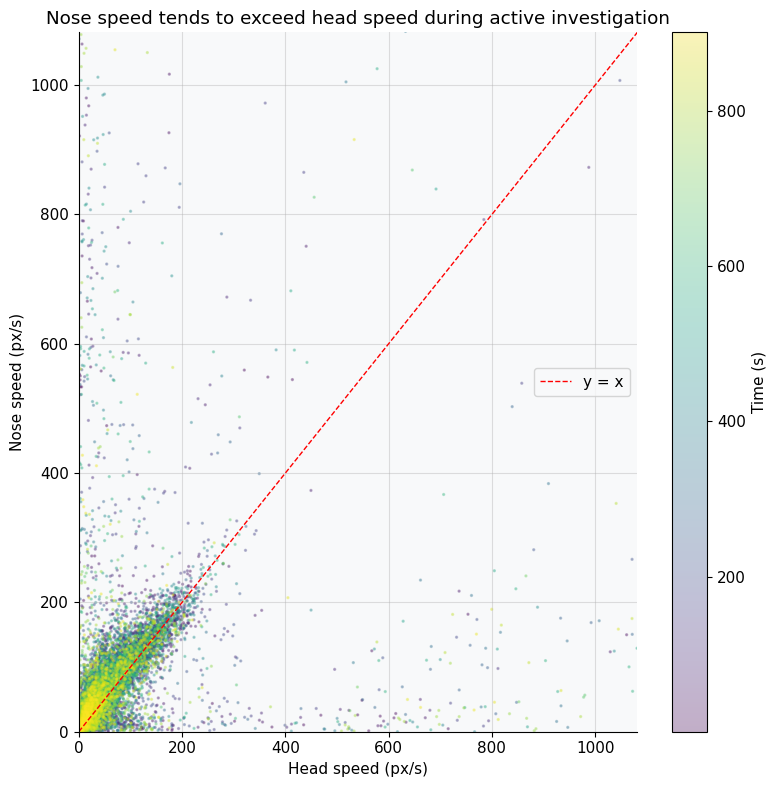

In [ ]:
# =============================================================================
# SOLUTION — Exercise 1
# =============================================================================
# Uncomment to reveal:

def calculate_head_speed(df, fps):
    dt = 1.0 / fps
    ## TODO: Compute head speed as the frame-to-frame distance traveled by the head divided by dt
    speed = None
    return np.concatenate([[np.nan], speed])

dlc['head_speed'] = calculate_head_speed(dlc, FPS)

fig, ax = plt.subplots(figsize=(8, 8))
valid = dlc.dropna(subset=['nose_speed', 'head_speed'])
sc = ax.scatter(valid['head_speed'], valid['nose_speed'],
                c=valid['time'], cmap='viridis', s=2, alpha=0.3)
plt.colorbar(sc, label='Time (s)')
max_val = max(valid['nose_speed'].quantile(0.99), valid['head_speed'].quantile(0.99))
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='y = x')
ax.set_xlabel('Head speed (px/s)')
ax.set_ylabel('Nose speed (px/s)')
ax.set_title('Nose speed tends to exceed head speed during active investigation')
ax.legend()
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
plt.tight_layout()
plt.show()

In [ ]:
# dx = np.diff(df['head_x'].values)
# dy = np.diff(df['head_y'].values)
# speed = np.sqrt(dx**2 + dy**2) / dt

---
## Part 5: Kinematics During Object Interaction vs. Free Exploration

A central question: **does the mouse move differently when investigating objects?**

In Findley et al., mice showed distinct kinematics during olfactory search (within-trial) vs. inter-trial intervals. Similarly, we can compare kinematics during object interaction vs. free exploration.

We reuse the interaction detection from Day 2.

In [58]:
# ─────────────────────────────────────────────────────────────
# Recompute object interaction flags (from Day 2)
# ─────────────────────────────────────────────────────────────
def compute_interaction_flags(df, obj_df, scale=1.5):
    """Add binary interaction columns for each object."""
    for _, row in obj_df.iterrows():
        obj = row['object']
        dist = np.sqrt(
            (df['nose_x'] - row['center_x'])**2 +
            (df['nose_y'] - row['center_y'])**2
        )
        w = row['bbox_x2'] - row['bbox_x1']
        h = row['bbox_y2'] - row['bbox_y1']
        ## TODO: Compute a distance threshold based on object size (e.g., half diagonal * scale)

        threshold = None
        df[f'dist_to_{obj}'] = dist
        df[f'interact_{obj}'] = (dist < threshold).astype(int)

    # Any-object interaction
    interact_cols = [c for c in df.columns if c.startswith('interact_')]
    df['interacting_any'] = df[interact_cols].max(axis=1)
    return df

dlc = compute_interaction_flags(dlc, obj_df, scale=1.5)

n_interact = dlc['interacting_any'].sum()
pct_interact = n_interact / len(dlc) * 100
print(f"✓ Interaction detected in {n_interact} frames ({pct_interact:.1f}% of session)")

✓ Interaction detected in 7725 frames (42.8% of session)


In [ ]:
# def compute_interaction_flags(df, obj_df, scale=1.5):
#     """Add binary interaction columns for each object."""
#     for _, row in obj_df.iterrows():
#         obj = row['object']
#         dist = np.sqrt(
#             (df['nose_x'] - row['center_x'])**2 +
#             (df['nose_y'] - row['center_y'])**2
#         )
#         w = row['bbox_x2'] - row['bbox_x1']
#         h = row['bbox_y2'] - row['bbox_y1']
#         half_diag = np.sqrt(w**2 + h**2) / 2
#         threshold = half_diag * scale
#         df[f'dist_to_{obj}'] = dist
#         df[f'interact_{obj}'] = (dist < threshold).astype(int)

#     # Any-object interaction
#     interact_cols = [c for c in df.columns if c.startswith('interact_')]
#     df['interacting_any'] = df[interact_cols].max(axis=1)
#     return df

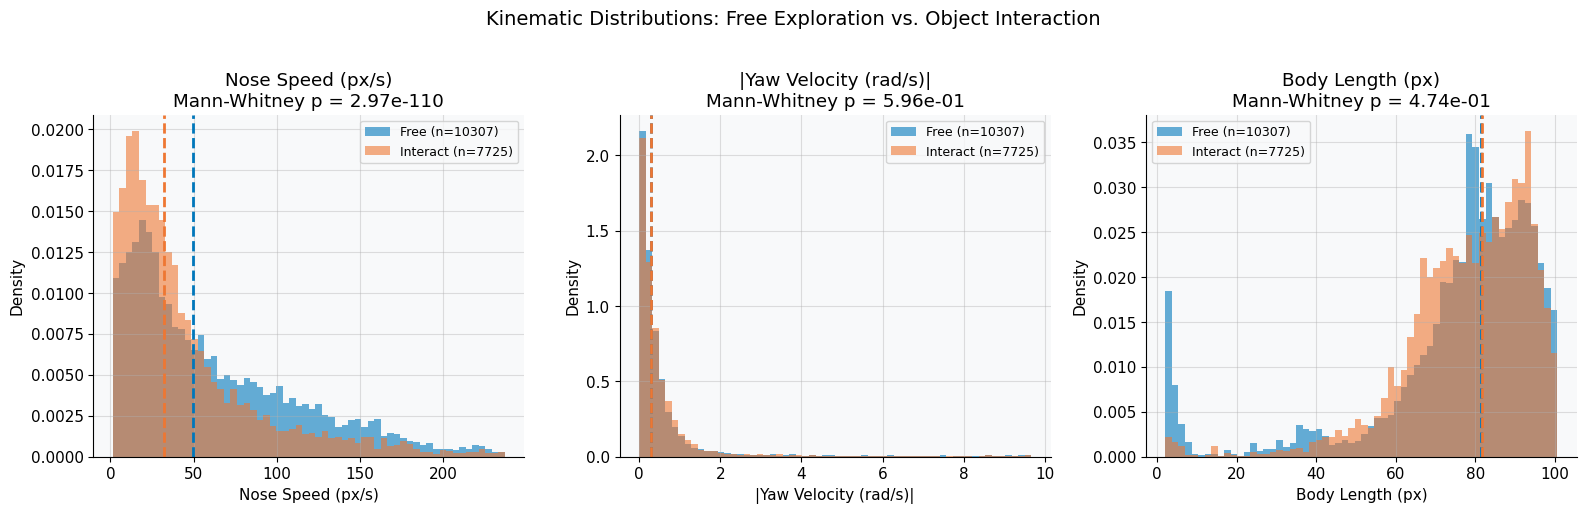

In [44]:
# ─────────────────────────────────────────────────────────────
# Compare kinematics: interacting vs. not interacting
# ─────────────────────────────────────────────────────────────

features_to_compare = {
    'nose_speed_smooth': ('Nose Speed (px/s)', False),
    'yaw_velocity_smooth': ('Yaw Velocity (rad/s)', True),  # True = show absolute
    'body_length': ('Body Length (px)', False),
}

interact_mask = dlc['interacting_any'] == 1
free_mask = dlc['interacting_any'] == 0

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, (label, use_abs)) in zip(axes, features_to_compare.items()):
    data_interact = dlc.loc[interact_mask, col].dropna()
    data_free = dlc.loc[free_mask, col].dropna()

    if use_abs:
        data_interact = np.abs(data_interact)
        data_free = np.abs(data_free)
        label = '|' + label + '|'
    ranges = (np.nanpercentile(data_free, 1), np.nanpercentile(data_free, 95))
    ax.hist(data_free, bins=60, alpha=0.6, density=True, color=CB_COLORS[0],
            label=f'Free (n={len(data_free)})', range=ranges)
    ax.hist(data_interact, bins=60, alpha=0.6, density=True, color=CB_COLORS[1],
            label=f'Interact (n={len(data_interact)})', range=ranges)

    # Median lines
    ax.axvline(data_free.median(), color=CB_COLORS[0], linestyle='--', linewidth=2)
    ax.axvline(data_interact.median(), color=CB_COLORS[1], linestyle='--', linewidth=2)

    # Mann-Whitney test
    u_stat, p_val = stats.mannwhitneyu(data_free, data_interact, alternative='two-sided')
    ax.set_title(f'{label}\nMann-Whitney p = {p_val:.2e}')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Kinematic Distributions: Free Exploration vs. Object Interaction', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Per-Object Kinematic Comparison

Different objects might elicit different investigation behaviors. Let's check.

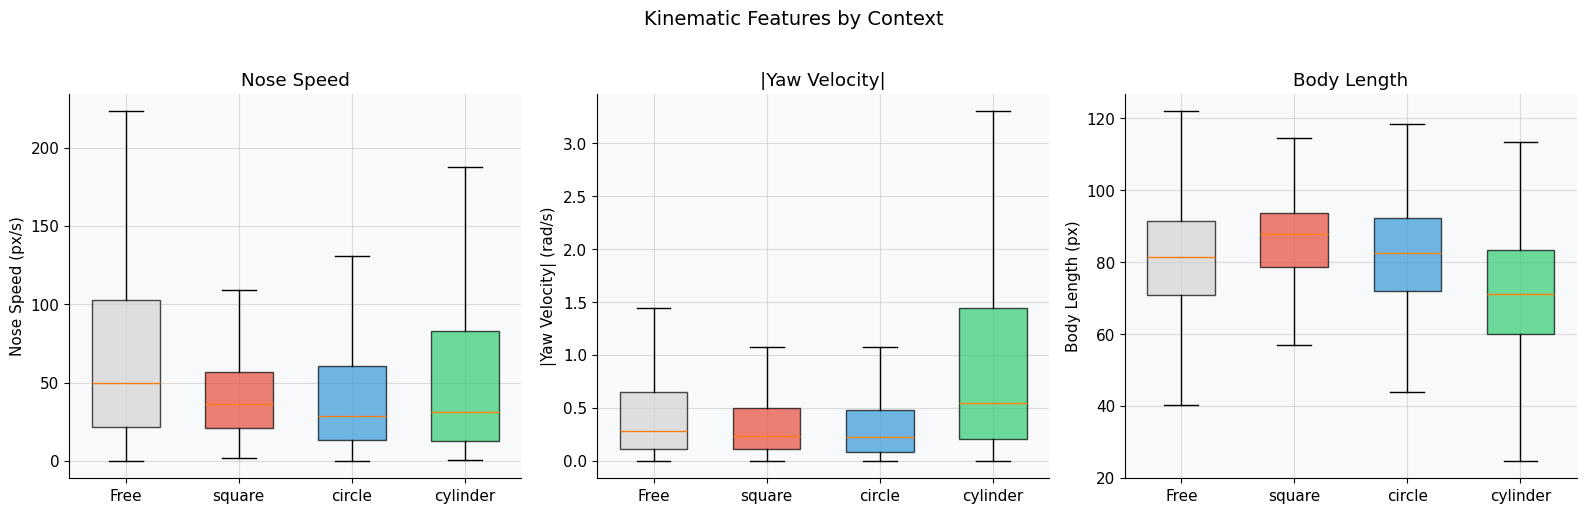

In [46]:
# ─────────────────────────────────────────────────────────────
# Per-object kinematic comparison
# ─────────────────────────────────────────────────────────────
COLORS_OBJ = {
    'object_1_square':   '#e74c3c',
    'object_2_circle':   '#3498db',
    'object_3_cylinder': '#2ecc71',
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (feat, ylabel) in zip(axes, [
    ('nose_speed_smooth', 'Nose Speed (px/s)'),
    ('yaw_velocity_smooth', '|Yaw Velocity| (rad/s)'),
    ('body_length', 'Body Length (px)'),
]):
    box_data = []
    box_labels = []
    box_colors = []

    # Free exploration baseline
    free_vals = dlc.loc[free_mask, feat].dropna()
    if 'yaw' in feat:
        free_vals = np.abs(free_vals)
    box_data.append(free_vals.values)
    box_labels.append('Free')
    box_colors.append('lightgray')

    for _, obj_row in obj_df.iterrows():
        obj = obj_row['object']
        obj_mask = dlc[f'interact_{obj}'] == 1
        vals = dlc.loc[obj_mask, feat].dropna()
        if 'yaw' in feat:
            vals = np.abs(vals)
        box_data.append(vals.values)
        short_name = obj.split('_')[-1]
        box_labels.append(short_name)
        box_colors.append(COLORS_OBJ.get(obj, 'gray'))

    bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,
                    showfliers=False, widths=0.6)
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel.split('(')[0].strip())

plt.suptitle('Kinematic Features by Context', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## ✏️ Exercise 2: Time-Resolved Kinematics Around Interaction Onset

When the mouse approaches an object, how do kinematics change over time?
Create a **peri-event plot** showing nose speed and yaw velocity aligned to the
onset of each interaction bout.

This is similar to the sniff-aligned averages in Findley et al. Figure 5.

In [ ]:
# =============================================================================
# EXERCISE 2: Peri-event kinematic analysis
# =============================================================================
# TODO: Detect interaction bout onsets (transitions from 0 → 1)
# TODO: Extract a window of ±2 seconds around each onset
# TODO: Average across bouts and plot with SEM

def peri_event_average(signal, event_indices, window_frames):
    """
    Extract and average signal around events.

    Parameters
    ----------
    signal        : 1D array     The kinematic signal
    event_indices : list of int  Frame indices of events
    window_frames : int          Half-window in frames

    Returns
    -------
    mean_trace : 1D array  (2*window_frames + 1,)
    sem_trace  : 1D array
    n_events   : int
    """
    # YOUR CODE HERE
    pass

# Find interaction onsets
# HINT: np.diff() on the binary signal; transitions are where diff == 1

# Plot peri-event averages
# HINT: Use fig, axes = plt.subplots(1, 2) for nose_speed and yaw_velocity

# Find onsets
interact_diff = np.diff(dlc['interacting_any'].values)
onset_frames = np.where(interact_diff == 1)[0] + 1

WINDOW_S = 2.0
window_frames = int(WINDOW_S * FPS)
time_axis = np.linspace(-WINDOW_S, WINDOW_S, 2 * window_frames + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (feat, label) in zip(axes, [
    ('nose_speed_smooth', 'Nose Speed (px/s)'),
    ('yaw_velocity_smooth', 'Yaw Velocity (rad/s)'),
]):
    signal = dlc[feat].values
    mean_t, sem_t, n_ev = peri_event_average(signal, onset_frames, window_frames)
    if mean_t is not None:
        ax.plot(time_axis, mean_t, color=CB_COLORS[0], linewidth=2)
        ax.fill_between(time_axis, mean_t - sem_t, mean_t + sem_t,
                        alpha=0.3, color=CB_COLORS[0])
    ax.axvline(0, color='red', linestyle='--', linewidth=1, label='Interaction onset')
    ax.set_xlabel('Time relative to onset (s)')
    ax.set_ylabel(label)
    ax.set_title(f'{label} around interaction onset (n={n_ev} bouts)')
    ax.legend()

plt.tight_layout()
plt.show()

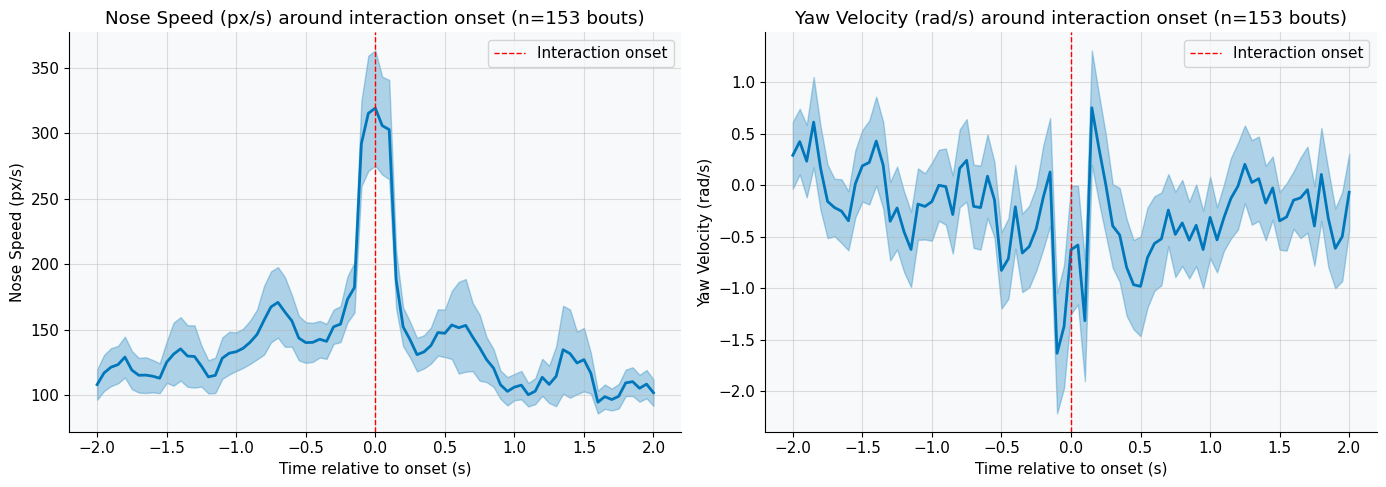

In [ ]:
# # =============================================================================
# # SOLUTION — Exercise 2
# # =============================================================================
# # Uncomment to reveal:

# def peri_event_average(signal, event_indices, window_frames):
#     traces = []
#     for idx in event_indices:
#         start = idx - window_frames
#         end = idx + window_frames + 1
#         if start >= 0 and end <= len(signal):
#             trace = signal[start:end]
#             if not np.any(np.isnan(trace)):
#                 traces.append(trace)
#     if len(traces) == 0:
#         return None, None, 0
#     traces = np.array(traces)
#     return np.mean(traces, axis=0), stats.sem(traces, axis=0), len(traces)


# 🤯 Disuccsion:

- How can we interpret the results?
- What would be the reason to explain it?
- What you would suggest to try out?


## The rest part will be bonus part. Feel free to explore!

---
## Part 6: Movement Motif Discovery

### Conceptual Background

Findley et al. used an **Auto-Regressive Hidden Markov Model (AR-HMM)** to parse continuous
movement trajectories into discrete "motifs" — short, recurring movement patterns.

The full AR-HMM is complex, so here we use a **simplified motif discovery pipeline**:

1. **Sliding window**: Extract overlapping windows of kinematic features
2. **Standardize**: Z-score each feature
3. **Dimensionality reduction**: PCA to remove correlated dimensions
4. **Clustering**: K-Means to group similar movement windows into motifs

This captures the core idea: find recurring patterns in multi-dimensional kinematic time series.

### Math: Sliding-Window Feature Vectors

For each time point $t$, we create a feature vector from a window of $w$ frames:

$$\mathbf{f}[t] = \begin{bmatrix} v_{\text{nose}}[t], & \dot{\psi}[t], & L_{\text{body}}[t], & \dot{L}_{\text{body}}[t], & \dot{\theta}_{\text{body}}[t] \end{bmatrix}$$

Then we average features within a window of $w$ frames to get a per-window summary:

$$\bar{\mathbf{f}}_i = \frac{1}{w} \sum_{t=iw}^{(i+1)w - 1} \mathbf{f}[t]$$

We also include the **standard deviation** within each window to capture variability.

In [59]:
# ─────────────────────────────────────────────────────────────
# Step 1: Build feature matrix from sliding windows
# ─────────────────────────────────────────────────────────────

FEATURE_COLS = ['nose_speed_smooth', 'yaw_velocity_smooth',
                'body_length', 'body_length_vel', 'body_angular_vel']

WINDOW_SIZE = 10  # frames = 0.5 s at 20 fps
STEP_SIZE   = 5   # frames = 0.25 s (50% overlap)

def build_window_features(df, feature_cols, window_size, step_size):
    """Build feature matrix from overlapping time windows."""
    features = df[feature_cols].values
    n_frames = len(features)
    n_features = len(feature_cols)

    windows = []
    window_times = []
    window_centers = []

    for start in range(0, n_frames - window_size, step_size):
        chunk = features[start:start + window_size]
        if np.any(np.isnan(chunk)):
            continue
        # Mean and std of each feature within the window
        mean_feat = np.mean(chunk, axis=0)
        std_feat = np.std(chunk, axis=0)
        windows.append(np.concatenate([mean_feat, std_feat]))
        window_times.append(df['time'].iloc[start + window_size // 2])
        window_centers.append(start + window_size // 2)

    feature_names = (
        [f'{c}_mean' for c in feature_cols] +
        [f'{c}_std' for c in feature_cols]
    )
    return np.array(windows), np.array(window_times), np.array(window_centers), feature_names

X_windows, window_times, window_centers, feat_names = build_window_features(
    dlc, FEATURE_COLS, WINDOW_SIZE, STEP_SIZE
)

print(f"✓ Built {X_windows.shape[0]} windows × {X_windows.shape[1]} features")
print(f"  Window = {WINDOW_SIZE/FPS:.2f}s, Step = {STEP_SIZE/FPS:.2f}s")
print(f"  Features: {feat_names}")

✓ Built 3604 windows × 10 features
  Window = 0.50s, Step = 0.25s
  Features: ['nose_speed_smooth_mean', 'yaw_velocity_smooth_mean', 'body_length_mean', 'body_length_vel_mean', 'body_angular_vel_mean', 'nose_speed_smooth_std', 'yaw_velocity_smooth_std', 'body_length_std', 'body_length_vel_std', 'body_angular_vel_std']


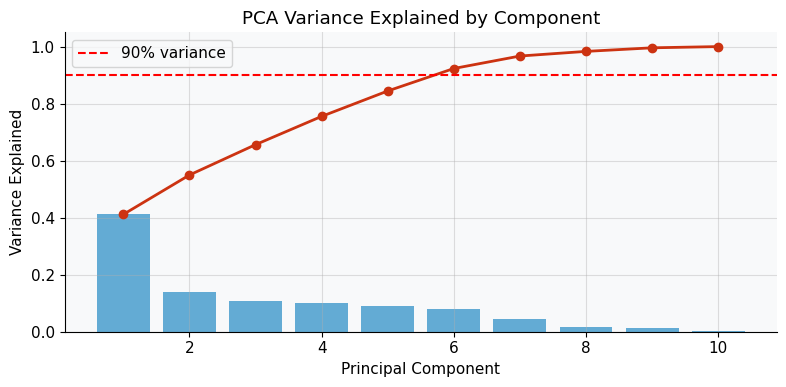


→ Keeping 6 PCs (explains 92.3% of variance)


In [60]:
# ─────────────────────────────────────────────────────────────
# Step 2: Standardize and reduce dimensionality
# ─────────────────────────────────────────────────────────────

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_windows)

# PCA
pca = PCA()
X_pca_full = pca.fit_transform(X_scaled)

# How many components to keep?
cumvar = np.cumsum(pca.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(cumvar)+1), pca.explained_variance_ratio_, alpha=0.6, color=CB_COLORS[0])
ax.plot(range(1, len(cumvar)+1), cumvar, 'o-', color=CB_COLORS[3], linewidth=2)
ax.axhline(0.90, color='red', linestyle='--', label='90% variance')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained')
ax.set_title('PCA Variance Explained by Component')
ax.legend()
plt.tight_layout()
plt.show()

n_components = np.argmax(cumvar >= 0.90) + 1
print(f"\n→ Keeping {n_components} PCs (explains {cumvar[n_components-1]*100:.1f}% of variance)")

X_pca = X_pca_full[:, :n_components]

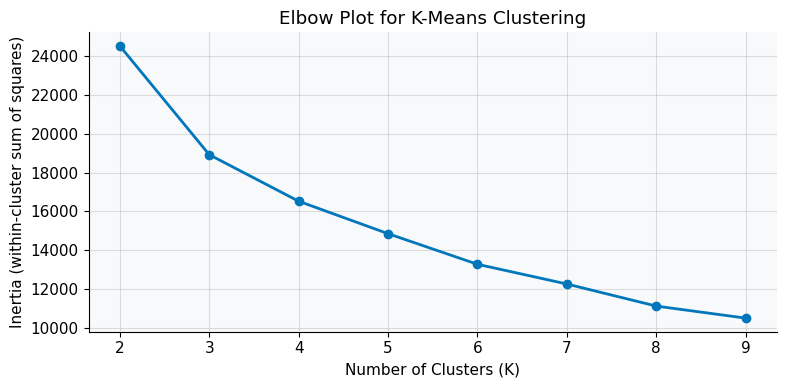


✓ Clustered into 5 motifs
  Motif 0: 3110 windows (86.3%)
  Motif 1: 82 windows (2.3%)
  Motif 2: 12 windows (0.3%)
  Motif 3: 184 windows (5.1%)
  Motif 4: 216 windows (6.0%)


In [61]:
# ─────────────────────────────────────────────────────────────
# Step 3: K-Means clustering to discover motifs
# ─────────────────────────────────────────────────────────────

# Try different numbers of clusters
K_range = range(2, 10)
inertias = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_range), inertias, 'o-', color=CB_COLORS[0], linewidth=2)
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (within-cluster sum of squares)')
ax.set_title('Elbow Plot for K-Means Clustering')
plt.tight_layout()
plt.show()

# Choose K (you can adjust based on the elbow)
K = 5
km_final = KMeans(n_clusters=K, random_state=42, n_init=20)
motif_labels = km_final.fit_predict(X_pca)

print(f"\n✓ Clustered into {K} motifs")
for k in range(K):
    count = np.sum(motif_labels == k)
    print(f"  Motif {k}: {count} windows ({count/len(motif_labels)*100:.1f}%)")

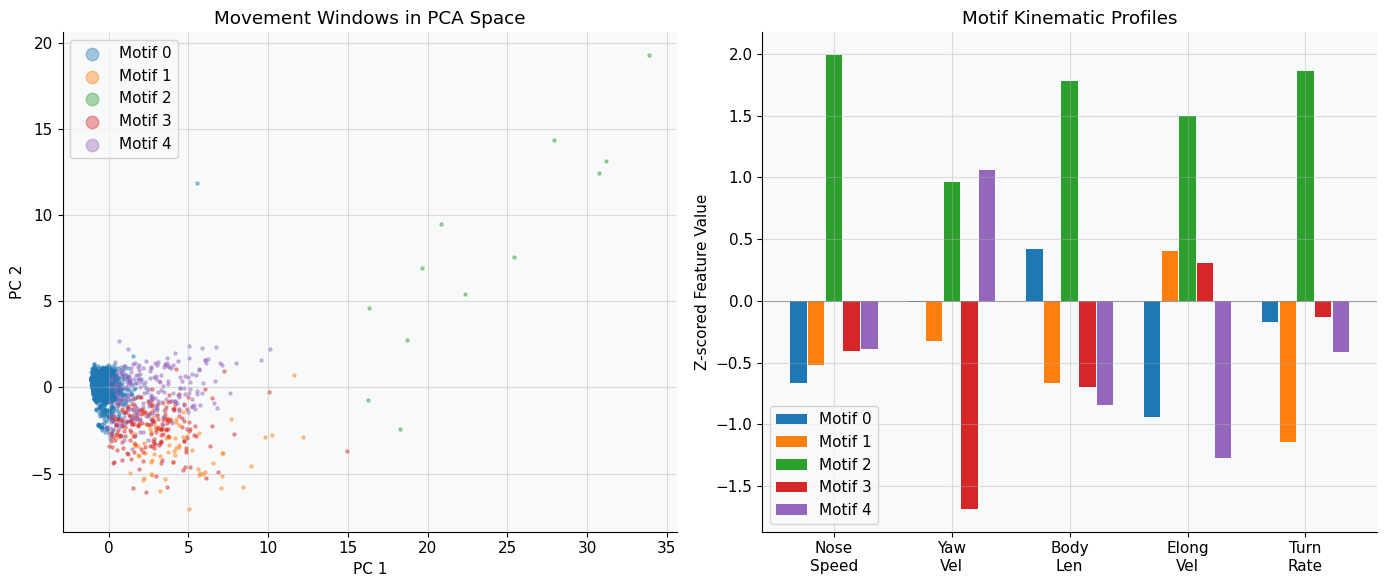

In [51]:
# ─────────────────────────────────────────────────────────────
# Visualize motifs in PCA space
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA scatter
for k in range(K):
    mask_k = motif_labels == k
    axes[0].scatter(X_pca[mask_k, 0], X_pca[mask_k, 1],
                    s=5, alpha=0.4, label=f'Motif {k}')
axes[0].set_xlabel('PC 1')
axes[0].set_ylabel('PC 2')
axes[0].set_title('Movement Windows in PCA Space')
axes[0].legend(markerscale=4)

# Motif profiles: mean kinematic features per motif
motif_profiles = np.zeros((K, len(FEATURE_COLS)))
for k in range(K):
    mask_k = motif_labels == k
    motif_profiles[k] = X_windows[mask_k, :len(FEATURE_COLS)].mean(axis=0)

short_names = ['Nose\nSpeed', 'Yaw\nVel', 'Body\nLen', 'Elong\nVel', 'Turn\nRate']
x_pos = np.arange(len(short_names))

for k in range(K):
    # Normalize to z-score for comparison
    profile_z = (motif_profiles[k] - motif_profiles.mean(axis=0)) / (motif_profiles.std(axis=0) + 1e-8)
    axes[1].bar(x_pos + k * 0.15, profile_z, width=0.14, label=f'Motif {k}')

axes[1].set_xticks(x_pos + 0.3)
axes[1].set_xticklabels(short_names)
axes[1].set_ylabel('Z-scored Feature Value')
axes[1].set_title('Motif Kinematic Profiles')
axes[1].legend()
axes[1].axhline(0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.show()

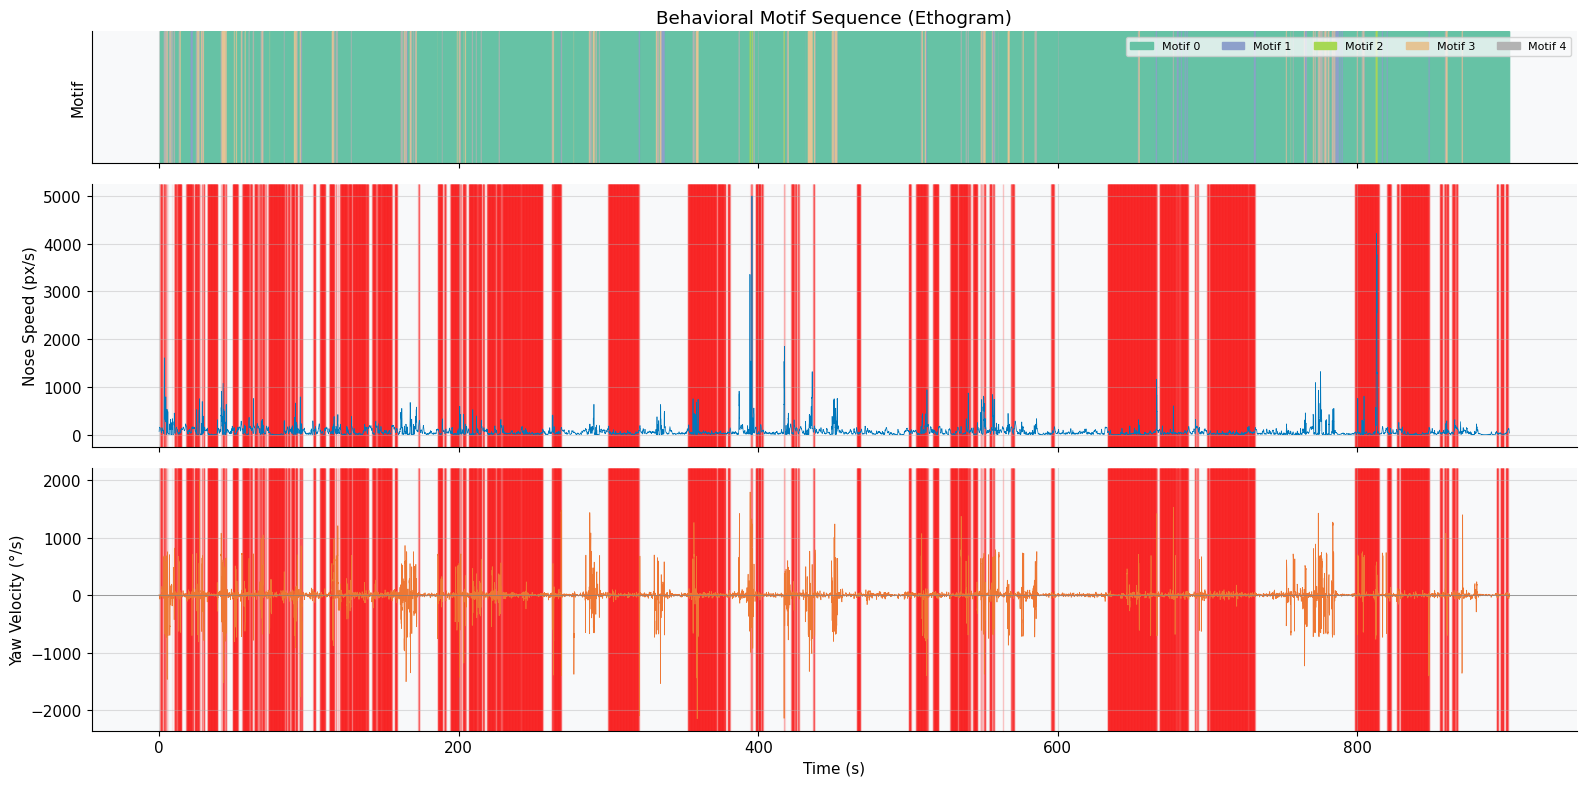

In [52]:
# ─────────────────────────────────────────────────────────────
# Motif sequence over time (ethogram)
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True,
                          gridspec_kw={'height_ratios': [1, 2, 2]})

# Top: motif ethogram
colors_motif = plt.cm.Set2(np.linspace(0, 1, K))
for i in range(len(motif_labels) - 1):
    axes[0].axvspan(window_times[i], window_times[i+1],
                     color=colors_motif[motif_labels[i]], alpha=0.8)
axes[0].set_yticks([])
axes[0].set_ylabel('Motif')
axes[0].set_title('Behavioral Motif Sequence (Ethogram)')

# Add legend
patches = [mpatches.Patch(color=colors_motif[k], label=f'Motif {k}') for k in range(K)]
axes[0].legend(handles=patches, loc='upper right', ncol=K, fontsize=8)

# Middle: nose speed
axes[1].plot(dlc['time'], dlc['nose_speed_smooth'], color=CB_COLORS[0], linewidth=0.5)
axes[1].set_ylabel('Nose Speed (px/s)')

# Bottom: yaw velocity
axes[2].plot(dlc['time'], np.degrees(dlc['yaw_velocity_smooth']),
             color=CB_COLORS[1], linewidth=0.5)
axes[2].axhline(0, color='gray', linewidth=0.5)
axes[2].set_ylabel('Yaw Velocity (°/s)')
axes[2].set_xlabel('Time (s)')

# Shade interaction periods
for ax in axes[1:]:
    interact_periods = dlc['interacting_any'].values
    for i in range(len(interact_periods) - 1):
        if interact_periods[i] == 1:
            ax.axvspan(dlc['time'].iloc[i], dlc['time'].iloc[i+1],
                       color='red', alpha=0.08)

plt.tight_layout()
plt.show()

---
## Part 7: Behavioral Grammar — Transition Matrix

Following Findley et al., we can ask: **how do motifs transition into each other?**
This reveals the "grammar" of behavior — which movements follow which.

### Math: Transition Matrix

A transition matrix $T$ captures the probability of switching from motif $i$ to motif $j$:

$$T_{ij} = P(\text{motif}[t+1] = j \mid \text{motif}[t] = i) = \frac{N_{i \to j}}{\sum_k N_{i \to k}}$$

where $N_{i \to j}$ is the count of transitions from state $i$ to state $j$.

If motifs cluster by their transition probabilities (as in Findley et al.), this can reveal
higher-order behavioral states like "investigation" vs. "approach".

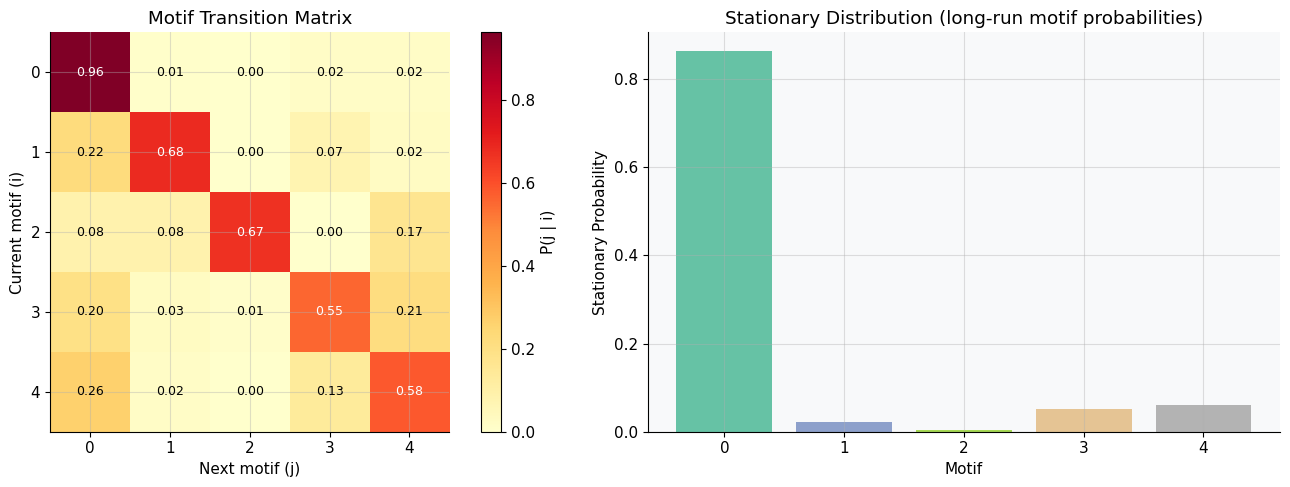

Transition matrix T:
[[0.964 0.005 0.001 0.015 0.015]
 [0.22  0.683 0.    0.073 0.024]
 [0.083 0.083 0.667 0.    0.167]
 [0.196 0.027 0.011 0.554 0.212]
 [0.264 0.019 0.    0.134 0.583]]


In [53]:
# ─────────────────────────────────────────────────────────────
# Build transition matrix from motif sequence
# ─────────────────────────────────────────────────────────────

def compute_transition_matrix(labels, n_states=None):
    """Compute row-normalized transition matrix from a label sequence."""
    if n_states is None:
        n_states = len(np.unique(labels))
    T = np.zeros((n_states, n_states))
    for i in range(len(labels) - 1):
        T[labels[i], labels[i+1]] += 1
    # Normalize rows
    row_sums = T.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1  # avoid division by zero
    T = T / row_sums
    return T

T = compute_transition_matrix(motif_labels, n_states=K)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transition matrix heatmap
im = axes[0].imshow(T, cmap='YlOrRd', vmin=0, vmax=np.max(T))
plt.colorbar(im, ax=axes[0], label='P(j | i)')
axes[0].set_xlabel('Next motif (j)')
axes[0].set_ylabel('Current motif (i)')
axes[0].set_title('Motif Transition Matrix')
for i in range(K):
    for j in range(K):
        axes[0].text(j, i, f'{T[i,j]:.2f}', ha='center', va='center', fontsize=9,
                     color='white' if T[i,j] > 0.3 else 'black')

# Stationary distribution
eigenvalues, eigenvectors = np.linalg.eig(T.T)
idx = np.argmax(np.abs(eigenvalues))
stationary = np.abs(eigenvectors[:, idx])
stationary = stationary / stationary.sum()

axes[1].bar(range(K), stationary, color=[colors_motif[k] for k in range(K)])
axes[1].set_xlabel('Motif')
axes[1].set_ylabel('Stationary Probability')
axes[1].set_title('Stationary Distribution (long-run motif probabilities)')

plt.tight_layout()
plt.show()

print("Transition matrix T:")
print(np.round(T, 3))

### 7.2 Motifs and Object Interaction

Which motifs occur more during object interaction? This helps interpret what each motif represents.

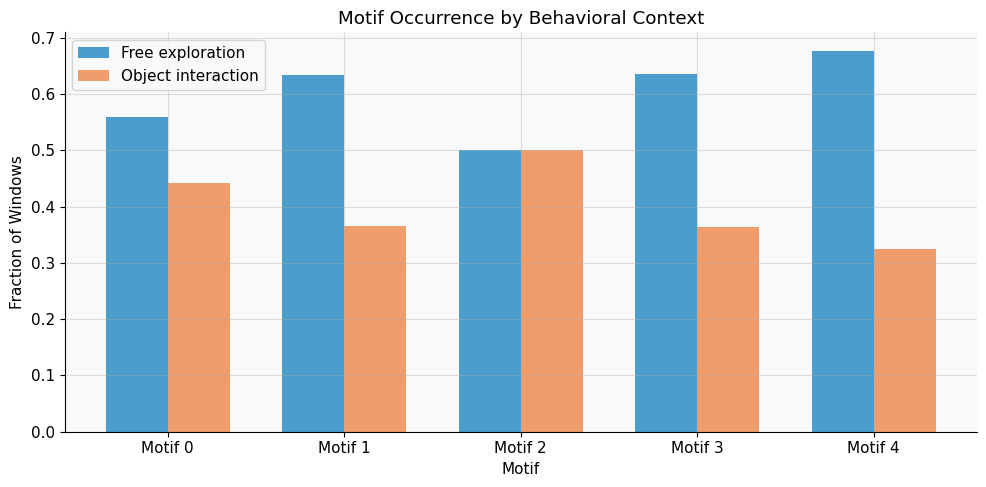

In [54]:
# ─────────────────────────────────────────────────────────────
# Motif prevalence during interaction vs. free exploration
# ─────────────────────────────────────────────────────────────
# Map window labels back to interaction state
window_interact = np.array([dlc['interacting_any'].iloc[c] for c in window_centers])

fig, ax = plt.subplots(figsize=(10, 5))

interact_frac = np.zeros(K)
free_frac = np.zeros(K)

for k in range(K):
    mask_k = motif_labels == k
    if mask_k.sum() > 0:
        interact_frac[k] = window_interact[mask_k].mean()
        free_frac[k] = 1 - interact_frac[k]

x = np.arange(K)
width = 0.35
ax.bar(x - width/2, free_frac, width, label='Free exploration',
       color=CB_COLORS[0], alpha=0.7)
ax.bar(x + width/2, interact_frac, width, label='Object interaction',
       color=CB_COLORS[1], alpha=0.7)
ax.set_xlabel('Motif')
ax.set_ylabel('Fraction of Windows')
ax.set_title('Motif Occurrence by Behavioral Context')
ax.set_xticks(x)
ax.set_xticklabels([f'Motif {k}' for k in range(K)])
ax.legend()

plt.tight_layout()
plt.show()

---
## 📋 Summary & Key Takeaways

### Pipeline Recap

```
DLC Keypoints (nose, head, spine1, spine2)
    │
    ├─ Quality control (Day 2: likelihood + interpolation + smoothing)
    │
    ├─ Kinematic Feature Extraction
    │      ├─ Nose speed (displacement of snout tip)
    │      ├─ Yaw velocity (head bending rate — head casting)
    │      ├─ Body length & elongation velocity
    │      └─ Body angular velocity (turning rate)
    │
    ├─ Behavioral Context Comparison
    │      ├─ Kinematics during object interaction vs. free exploration
    │      └─ Per-object kinematic differences
    │
    └─ Motif Discovery
           ├─ Sliding-window feature extraction
           ├─ PCA + K-Means clustering → motifs
           ├─ Transition matrix → behavioral grammar
```

### Key Concepts

1. **Explainable features** (Findley-style) vs. **learned features** (MoSeq-style): both are valid!
   We extracted features with clear biomechanical meaning — nose speed tells us about locomotion
   vigor, yaw velocity about active sensing, and body length about postural extension.

2. **Behavioral context matters**: The same kinematic measures show different distributions
   during object interaction vs. free exploration, paralleling Findley's within-trial vs. ITI differences.

3. **Motif discovery** reveals recurring movement patterns without human labeling bias.
   Clustering motifs by their transition probabilities can reveal higher-order behavioral states.

4. **Noisy data is normal**: Real DLC tracking is imperfect. Having a diagnostic toolkit
   (speed outliers, body-length anomalies) helps catch problems early.

### Connection to Other Days
- **Day 1**: The rotation/transformation math underlies how we compute yaw angles
- **Day 2**: Data loading, cleaning, and interaction detection are reused directly
- **Day 3**: Change-point detection (ruptures) could segment the motif sequence
- **Day 5**: Transition matrices connect to HMMs and behavioral grammar

### References
- Findley et al. (2021). *Sniff-synchronized, gradient-guided olfactory search by freely moving mice.* eLife, 10, e58523.
- Wiltschko et al. (2015). *Mapping Sub-Second Structure in Mouse Behavior.* Neuron.
- Mathis et al. (2018). *DeepLabCut: markerless pose estimation.* Nature Neuroscience.

### Extension Ideas
- Try `ruptures` to find change-points in the motif sequence
- Apply Savitzky-Golay filtering instead of uniform smoothing and compare
- Use `hmmlearn` to fit a proper HMM instead of K-Means
- Compute cross-correlation between nose speed and yaw velocity (as in Findley et al.)